## 18.3. Gaussian Process Inference

### 18.3.1. Posterior Inference for Regression

$$
y(x) = f(x) + ϵ(x)
$$

inputs: 
$$
X_* = x_{*1}, x_{*2}, ..., x_{*m}
$$

$$
\left[\begin{aligned}
  \textbf{y} \\ 
  \textbf{f}_* 
\end{aligned}\right] ∼ \mathcal{N}(0, \textbf{A} = 
\left[
  \begin{aligned}
  K(X, X) + σ^2 I &\quad K(X, X_*) \\ 
  K(X_*, X) &\quad K(X_*, X_*) 
  \end{aligned}
\right])
$$

In [2]:
import math
import os
import gpytorch
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import optimize
from scipy.spatial import distance_matrix
from d2l import torch as d2l

d2l.set_figsize()

### 18.3.2. Equations for Making Predictions and Learning Kernel Hyperparameters in GP Regression

$$
\log p(\textbf{y} | θ, \textbf{X}) = -\frac12\textbf{y}^T[K_θ(x, x) + σ^2 I]^{-1}\textbf{y} - \frac12\log|K_θ(X, X)| + c
$$

$$
p(y_*|x_*, \textbf{y}, θ) = \mathcal{N}(a_*, v_*) \\ 
a_* = k_θ(x_*, X)[K_θ(X, X) + σ^2I]^{-1}(\textbf{y} - μ) + μ \\ 
v_* = k_θ(x_*, x_*) - K_θ(x_*, X)[K_θ(X, X) + σ^2I]^{-1}k_θ(X, x_*)
$$

### 18.3.3. Interpreting Equations for Learning and Predictions

$$
y(x) = \sin(x) + \frac12\sin(4x) + ϵ
$$

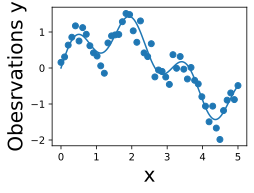

In [4]:
def data_maker1(x, sig):
  return np.sin(x) + 0.5 * np.sin(4 * x) + np.random.randn(x.shape[0]) * sig

sig = 0.25
train_x, test_x = np.linspace(0, 5, 50), np.linspace(0, 5, 500)
train_y, test_y = data_maker1(train_x, sig=sig), data_maker1(test_x, sig=0.)

d2l.plt.scatter(train_x, train_y)
d2l.plt.plot(test_x, test_y)
d2l.plt.xlabel("x", fontsize=20)
d2l.plt.ylabel("Obesrvations y", fontsize=20)
d2l.plt.show()

$$
k(x_i, x_j) = a^2\exp(-\frac{1}{2ℓ^2}||x - x'||^2)
$$

In [5]:
mean = np.zeros(test_x.shape[0])
cov = d2l.rbfkernel(test_x, test_x, ls=0.2)

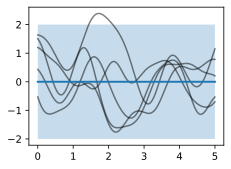

In [6]:
prior_samples = np.random.multivariate_normal(mean=mean, cov=cov, size=5)
d2l.plt.plot(test_x, prior_samples.T, color='black', alpha=0.5)
d2l.plt.plot(test_x, mean, linewidth=2.)
d2l.plt.fill_between( test_x, mean - 2 * np.diag(cov), mean + 2 * np.diag(cov), 
                      alpha=0.25)
d2l.plt.show()

$$
\bar{f}_* = K(x, x_*)^T(K(x, x) + σ^2 I)^{-1}y \\ 
V(f_*) = K(x_*, x_*) - K(x, x_*)^T(K(x, x) + σ^2 I)^{-1} K(x, x_*)
$$

$$
\log p(y|\textbf{X}) = \log \int p(y | f, X)p(f | X) df \\ 
\log p(y | X) = -\frac12y^T(K(x, x) + σ^2 I)^{-1}y - \frac12\log|K(x, x) + σ^2I| - \frac{n}{2}\log 2π
$$

In [7]:
ell_est = 0.4
post_sig_est = 0.5

def neg_MLL(pars):
  K = d2l.rbfkernel(train_x, train_x, ls=pars[0])
  kernel_term = -0.5*train_y@ \
    np.linalg.inv(K + pars[1] ** 2 * np.eye(train_x.shape[0])) @ train_y
  lodget = -0.5 * np.log(np.linalg.det(K + pars[1] ** 2 * \
    np.eye(train_x.shape[0])))
  const = -train_x.shape[0] / 2. * np.log(2 * np.pi)
  return -(kernel_term + lodget + const)

learned_hypers = optimize.minimize(neg_MLL, x0=np.array([ell_est, post_sig_est]),
                                    bounds=((0.01, 10.), (0.01, 10.)))
ell = learned_hypers.x[0]
post_sig_est = learned_hypers.x[1]

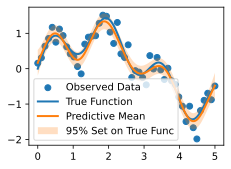

In [8]:
K_x_xstar = d2l.rbfkernel(train_x, test_x, ls=ell)
K_x_x = d2l.rbfkernel(train_x, train_x, ls=ell)
K_xstar_xstar = d2l.rbfkernel(test_x, test_x, ls=ell)

post_mean = K_x_xstar.T @ np.linalg.inv((K_x_x + \
  post_sig_est ** 2 * np.eye(train_x.shape[0]))) @ train_y
post_cov = K_xstar_xstar - K_x_xstar.T @ np.linalg.inv((K_x_x + \
  post_sig_est ** 2 * np.eye(train_x.shape[0]))) @ K_x_xstar

lw_bd = post_mean - 2 * np.sqrt(np.diag(post_cov))
up_bd = post_mean + 2 * np.sqrt(np.diag(post_cov))

d2l.plt.scatter(train_x, train_y)
d2l.plt.plot(test_x, test_y, linewidth=2)
d2l.plt.plot(test_x, post_mean, linewidth=2)
d2l.plt.fill_between(test_x, lw_bd, up_bd, alpha=0.25)
d2l.plt.legend(['Observed Data', 'True Function', 'Predictive Mean', '95% Set on True Func'])
d2l.plt.show()

In [9]:
lw_bd_observed = post_mean - 2 * np.sqrt(np.diag(post_cov) + post_sig_est ** 2)
up_bd_observed = post_mean + 2 * np.sqrt(np.diag(post_cov) + post_sig_est ** 2)

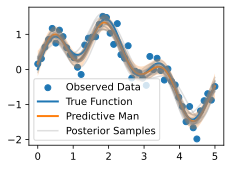

In [10]:
post_samples = np.random.multivariate_normal(post_mean, post_cov, size=20)
d2l.plt.scatter(train_x, train_y)
d2l.plt.plot(test_x, test_y, linewidth=2.)
d2l.plt.plot(test_x, post_mean, linewidth=2.)
d2l.plt.plot(test_x, post_samples.T, color='gray', alpha=0.25)
d2l.plt.fill_between(test_x, lw_bd, up_bd, alpha=0.25)
plt.legend(['Observed Data', 'True Function', 'Predictive Man', 'Posterior Samples'])
d2l.plt.show()

### 18.3.5 Making Life Easy with  GPyTorch

In [14]:
# First let's convert our data into tensors for use with PyTorch
train_x = torch.tensor(train_x)
train_y = torch.tensor(train_y)
test_y = torch.tensor(test_y)

# We re using exact GP inference with a zero mean and RBF kernel
class ExactGPModel(gpytorch.models.ExactGP):
  def __init__(self, train_x, train_y, likelihood):
    super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
    self.mean_module = gpytorch.means.ZeroMean()
    self.covar_module = gpytorch.kernels.ScaleKernel(
      gpytorch.kernels.RBFKernel()
    )
    
  def forward(self, x):
    mean_x = self.mean_module(x)
    covar_x = self.covar_module(x)
    return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

C:\Users\fanyu\AppData\Local\Temp\ipykernel_17876\2923281963.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_x = torch.tensor(train_x)
C:\Users\fanyu\AppData\Local\Temp\ipykernel_17876\2923281963.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(train_y)
C:\Users\fanyu\AppData\Local\Temp\ipykernel_17876\2923281963.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y = torch.tensor(test_y)


In [15]:
# Initialize Gaussian Likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)
training_iter = 50
# Find optimal model hyperparameters
model.train()
likelihood.train()
# Use the adam optimizer, includes GaussianLikelihood parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
# Set our loss as the negative log GP marginal likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

In [17]:
for i in range(training_iter):
  # Zero gradients from previous, iteration
  optimizer.zero_grad()
  # Output from model
  output = model(train_x)
  # Calc loss and backprop gradients
  loss = -mll(output, train_y)
  loss.backward()
  if i % 10 == 0:
    print(f'Iter {i+1:d} / {training_iter:d} - Loss: {loss.item():.3f} '
          f'squared lengthscle: '
          f'{model.covar_module.base_kernel.lengthscale.item():.3f} '
          f'noise variance: {model.likelihood.noise.item():.3f}')
  optimizer.step()

Iter 1 / 50 - Loss: 0.996 squared lengthscle: 0.693 noise variance: 0.693
Iter 11 / 50 - Loss: 0.718 squared lengthscle: 0.514 noise variance: 0.313
Iter 21 / 50 - Loss: 0.483 squared lengthscle: 0.514 noise variance: 0.129
Iter 31 / 50 - Loss: 0.408 squared lengthscle: 0.481 noise variance: 0.060
Iter 41 / 50 - Loss: 0.422 squared lengthscle: 0.483 noise variance: 0.049


In [18]:
# Get into evaluation (predictive posterior) mode
test_x = torch.tensor(test_x)
model.eval()
likelihood.eval()
observed_pred = likelihood(model(test_x))

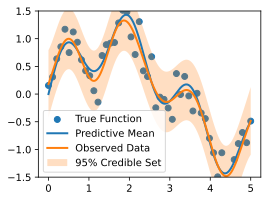

In [19]:
with torch.no_grad():
  # Initialize plot
  f, ax = d2l.plt.subplots(1, 1, figsize=(4, 3))
  # Get upper and lower bounds for 95\% credible set (in this case, in
  # observation space)
  lower, upper = observed_pred.confidence_region()
  ax.scatter(train_x.numpy(), train_y.numpy())
  ax.plot(test_x.numpy(), test_y.numpy(), linewidth=2)
  ax.plot(test_x.numpy(), observed_pred.mean.numpy(), linewidth=2)
  ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.25)
  ax.set_ylim([-1.5, 1.5])
  ax.legend(['True Function', 'Predictive Mean', 'Observed Data', '95% Credible Set'])